## 留意事項
- 本資料は教育・情報提供を目的としたもので、特定銘柄の売買推奨ではありません。
- バックテスト結果は将来成果を保証しません。
- 実運用は自己責任で行ってください。

# 4/23 botter会_先物乖離_クロスセクション戦略


> **対象**: 裁量取引の経験をベースに、AIを活用した戦略実装・自動化を実践している方<br>

![botterkai](botterkai.jpeg)

---

## 宿題のおさらい

| 宿題 | 内容 |
|------|------|
| ① 前提の検証 | 全銘柄対象で「乖離の絶対値が大きくなればなるほどリターンが上がるか」を検証 |
| ② バックテスト | 毎日、乖離がプラス上位10銘柄をショート ＋ マイナス上位10銘柄をロング、日々組み替え |


## これまでの流れ

| 回 | 日付 | テーマ | 主な結論 |
|---|---|---|---|
| 01 | 2026-02-26 | BTCで先物乖離の基礎確認 | Z-Score逆張りは「使えそうな指標」 |
| 02-1 | 2026-03-12 | アルトコイン362銘柄に拡張 | 63%の銘柄でSharpe > 0、上場が新しい銘柄が上位に多い |
| 02-2 | 2026-03-12 | コスト分析 | 手数料込みでも日足なら優位性あり |
| 02-3 | 2026-03-12 | 時間足の比較 | 日足が最優秀。短い足ほどコストに食われる |
| 02-4 | 2026-03-26 | 上場タイミングとワースト銘柄の分析 | 上場1ヶ月目の優位性を確認、ワースト銘柄の95%は「方向不一致型」|
| 02-5 | 2026-04-09 | 銘柄選択フィルタの検証 | 「稼げる銘柄」を事前に見分けられるか？ |
| **今回** | **2026-04-21** | **クロスセクション戦略の検証** | **銘柄群を毎日入れ替える戦略は機能するか？** |


---

## 目次

1. [環境セットアップ・データ読み込み](#section0)
2. [宿題① 「乖離の絶対値が大きいほどリターンが大きいか？」](#section1)
3. [宿題② 「クロスセクションのバックテスト」](#section2)
   - [補足検証: なぜロングではなくショートを選んだか？](#section-long-short)
4. [クロスセクション戦略の改良（ショートのみ版）](#section3)


<a id="section0"></a>
---
## 0. 環境セットアップ・データ読み込み

### 使用データ
- **Binanceデータ（2021年〜2026年）**: 現物価格・先物価格・出来高の日次データ  
- 371銘柄、約33万件のレコード

### 主要な指標の定義

| 指標 | 計算式 | 意味 |
|------|--------|------|
| `basis`（乖離率） | `(先物価格 - 現物価格) / 現物価格` | プラス = コンタンゴ（先物プレミアム）、マイナス = バックワーデーション |
| `roll_vol`（30日平均出来高） | `先物出来高の30日ローリング平均`（コイン枚数、価格乗算なし） | 流動性フィルタに使用 |
| `next_ret`（翌日リターン） | `翌日先物価格 / 当日先物価格 - 1` | バックテストのリターン計算に使用 |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# --- グラフの見た目設定 ---
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = ['Hiragino Sans', 'sans-serif']

# ==============================
# パラメータ（先生向けノートブックと同じ値）
# ==============================
FEE     = 0.0004   # 0.04%片道（往復0.08%）
THR     = 0.001    # 乖離率 > 0.1%
VOL_THR = 50e6     # 30日出来高 < 50M コイン枚数
BTC_THR = 0.10     # BTC 30日リターン > +10% で休む

# ==============================
# データ読み込み（Binance 2021-2026）
# ==============================
csv_path = Path('/Users/ryo.kondo/Desktop/名称未設定フォルダ 2/master_2021.csv')
if not csv_path.exists():
    raise FileNotFoundError(f"master_2021.csv not found: {csv_path}")

df = pd.read_csv(csv_path, parse_dates=['timestamp'])
df = df.rename(columns={
    'timestamp'    : 'date',
    'spot_close'   : 'sp_close',
    'spot_vol'     : 'sp_vol',
    'future_close' : 'fu_close',
    'future_vol'   : 'fu_vol'
})
df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None)
df = df.sort_values(['symbol', 'date'])

# 乖離率（basis）を計算
df['basis'] = (df['fu_close'] - df['sp_close']) / df['sp_close']

# ⚠️ roll_vol = 先物コイン枚数の30日平均（価格をかけない）
df['roll_vol'] = df.groupby('symbol')['fu_vol'].transform(
    lambda x: x.rolling(30, min_periods=15).mean())

# 翌日リターン（先物価格ベース）
df['next_ret'] = df.groupby('symbol')['fu_close'].transform(
    lambda x: x.pct_change().shift(-1))

# 翌日の現物価格リターン（宿題①・②の検証で使用）
df['next_sp_ret'] = df.groupby('symbol')['sp_close'].transform(
    lambda x: x.pct_change().shift(-1))

df = df.dropna(subset=['basis', 'roll_vol', 'next_ret'])
df = df.sort_values(['date', 'symbol']).reset_index(drop=True)

# BTC 30日リターン（BTCフィルター用）
btc = df[df['symbol'] == 'BTC'].set_index('date')['fu_close']
btc_ret30 = btc.pct_change(30)

# ==============================
# 共通ヘルパー関数
# ==============================
def sharpe(r):   return r.mean() / r.std() * np.sqrt(365) if r.std() > 0 else 0
def maxdd(r):    c = r.cumsum(); return (c - c.cummax()).min() * 100
def winrate(r):  return (r > 0).mean() * 100

print(f'データ期間: {df["date"].min().date()} 〜 {df["date"].max().date()}')
print(f'銘柄数    : {df["symbol"].nunique()} 銘柄')
print(f'総レコード: {len(df):,} 件')
print('✅ 準備完了')

データ期間: 2021-01-15 〜 2026-04-09
銘柄数    : 371 銘柄
総レコード: 327,461 件
✅ 準備完了


<a id="section1"></a>
---
## 宿題① 「乖離の絶対値が大きいほどリターンが大きいか？」

### 仮説

先物乖離戦略の直感的な考え方:

> 「先物と現物の価格差（乖離）が大きいほど、収束したときに得られる利益も大きいはず」

これは本当に成り立つのでしょうか？

### 検証方法

1. **対象**: `basis > 0`（先物プレミアム）の全日・全銘柄のデータ（0クロス条件なし）
2. **分割**: basis 絶対値を **10分位（D1〜D10）** に分ける
   - D1 = 乖離が最も小さいグループ
   - D10 = 乖離が最も大きいグループ
3. **リターン**: 翌日のショートリターン = `-next_ret`（先物価格ベース）
4. **評価指標**: 各分位の**中央値リターン**（外れ値の影響を除くため平均ではなく中央値）

### 予想される結果（仮説通りなら）

```
D1（小）→ D10（大）と進むにつれて、リターンが単調に増加する
```


In [3]:
# ============================================================
# 宿題①: basis > 0 の全日・全銘柄で 10分位別リターンを検証
# ============================================================
print('=== 宿題①: 乖離の絶対値が大きいほどリターンが大きいか？ ===')
print(f'検証対象: basis > 0 の全レコード')

# basis > 0 のデータのみ抽出
positive_basis = df[df['basis'] > 0].copy()
print(f'対象レコード数: {len(positive_basis):,} 件')
print()

# basis絶対値を10分位に分割
positive_basis['decile'] = pd.qcut(
    positive_basis['basis'],
    q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)

# ショートリターン = -next_ret（先物ショートで利益を得るため符号反転）
positive_basis['short_ret'] = -positive_basis['next_ret']

# 各分位の中央値リターンを計算
decile_stats = positive_basis.groupby('decile', observed=True).agg(
    median_ret  = ('short_ret', 'median'),
    mean_ret    = ('short_ret', 'mean'),
    count       = ('short_ret', 'count'),
    basis_min   = ('basis', 'min'),
    basis_max   = ('basis', 'max'),
).reset_index()

print('【分位別 中央値リターン（ショート）】')
print(f'{"分位":<8} {"中央値リターン":>14} {"件数":>8} {"basis範囲":>20}')
print('-' * 55)
for _, row in decile_stats.iterrows():
    flag = ' ← 最大乖離' if row['decile'] == 'D10' else ('  ← 最小乖離' if row['decile'] == 'D1' else '')
    print(f'{row["decile"]:<8} {row["median_ret"]*100:>+13.3f}%  {row["count"]:>8,}  '
          f'[{row["basis_min"]*100:.3f}%〜{row["basis_max"]*100:.3f}%]{flag}')

print()
print('→ D1〜D10で単調増加しているか確認してください')

=== 宿題①: 乖離の絶対値が大きいほどリターンが大きいか？ ===
検証対象: basis > 0 の全レコード
対象レコード数: 82,560 件

【分位別 中央値リターン（ショート）】
分位              中央値リターン       件数              basis範囲
-------------------------------------------------------
D1              +0.343%     8,256  [0.000%〜0.020%]  ← 最小乖離
D2              +0.129%     8,258  [0.020%〜0.034%]
D3              +0.143%     8,255  [0.034%〜0.049%]
D4              +0.154%     8,256  [0.049%〜0.064%]
D5              +0.044%     8,257  [0.064%〜0.079%]
D6              +0.044%     8,255  [0.079%〜0.097%]
D7              +0.014%     8,255  [0.097%〜0.117%]
D8              -0.000%     8,258  [0.117%〜0.143%]
D9              -0.055%     8,256  [0.143%〜0.187%]
D10             +0.284%     8,254  [0.187%〜17.460%] ← 最大乖離

→ D1〜D10で単調増加しているか確認してください


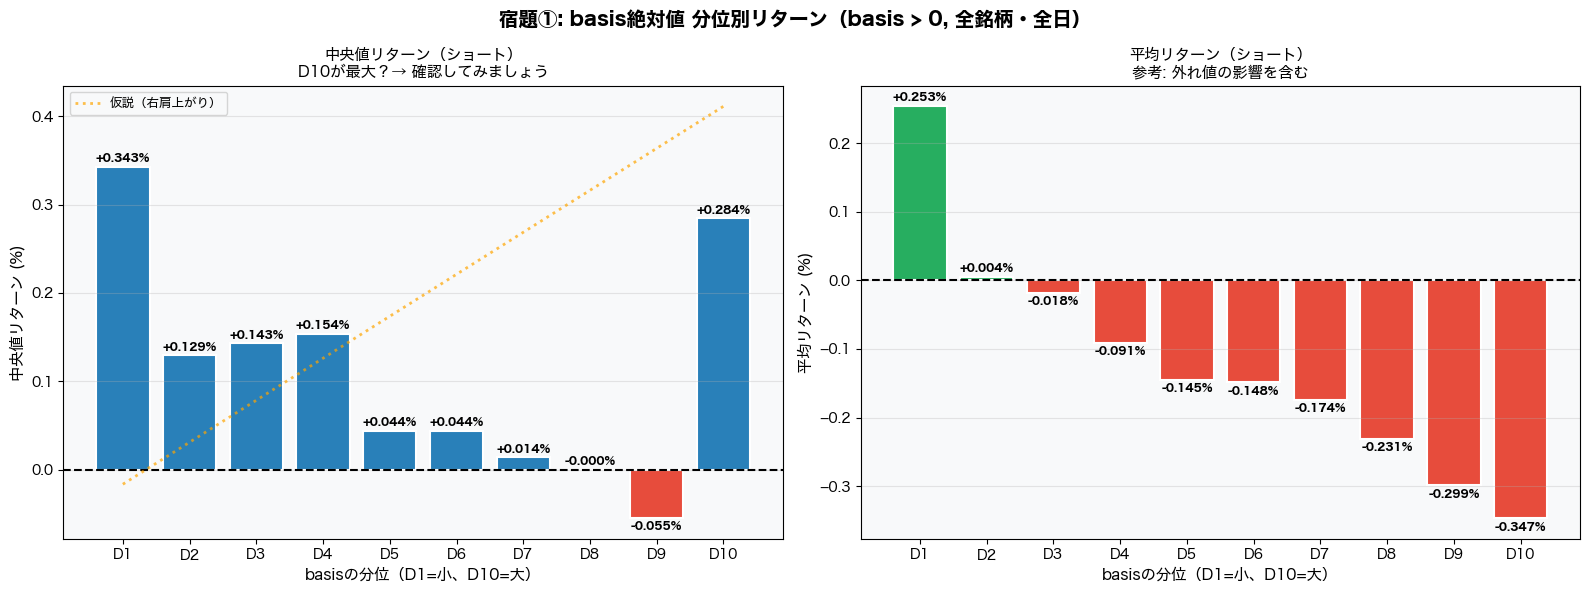

In [4]:
# ============================================================
# 可視化: 分位別 中央値リターン（棒グラフ）
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('宿題①: basis絶対値 分位別リターン（basis > 0, 全銘柄・全日）',
             fontsize=14, fontweight='bold')

# --- 左: 中央値リターン ---
ax1 = axes[0]
colors1 = ['#E74C3C' if v < 0 else '#2980B9' for v in decile_stats['median_ret']]
bars1 = ax1.bar(decile_stats['decile'], decile_stats['median_ret'] * 100,
                color=colors1, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, decile_stats['median_ret'] * 100):
    offset = 0.003 if val >= 0 else -0.003
    ax1.text(bar.get_x() + bar.get_width()/2, val + offset,
             f'{val:+.3f}%', ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=8, fontweight='bold')
ax1.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax1.set_xlabel('basisの分位（D1=小、D10=大）', fontsize=11)
ax1.set_ylabel('中央値リターン (%)', fontsize=11)
ax1.set_title('中央値リターン（ショート）\nD10が最大？→ 確認してみましょう', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# 「仮説通りなら右肩上がり」の補助線
x_pos = range(len(decile_stats))
y_min = decile_stats['median_ret'].min() * 100
y_max = decile_stats['median_ret'].max() * 100
ax1.plot(x_pos, np.linspace(y_min * 0.3, y_max * 1.2, len(decile_stats)),
         color='orange', linewidth=2, linestyle=':', alpha=0.7, label='仮説（右肩上がり）')
ax1.legend(fontsize=9)

# --- 右: 平均リターン（比較用）---
ax2 = axes[1]
colors2 = ['#E74C3C' if v < 0 else '#27AE60' for v in decile_stats['mean_ret']]
bars2 = ax2.bar(decile_stats['decile'], decile_stats['mean_ret'] * 100,
                color=colors2, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, decile_stats['mean_ret'] * 100):
    offset = 0.005 if val >= 0 else -0.005
    ax2.text(bar.get_x() + bar.get_width()/2, val + offset,
             f'{val:+.3f}%', ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=8, fontweight='bold')
ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax2.set_xlabel('basisの分位（D1=小、D10=大）', fontsize=11)
ax2.set_ylabel('平均リターン (%)', fontsize=11)
ax2.set_title('平均リターン（ショート）\n参考: 外れ値の影響を含む', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 検証結果のまとめ

**結論: 仮説は成立しない（むしろ逆の傾向）**

グラフを見ると:
- D1〜D10で単調に右肩上がりにはなっていない
- 乖離が大きい D9・D10 のリターンは D1〜D5 より低いか、マイナスになることもある

### なぜ「乖離大 = リターン大」にならないのか？

直感的には「乖離が大きいほど収束幅も大きく、リターンも大きい」と思えるが、実際には以下の理由で成り立たない:

#### 理由1: ファンディングレートが「乖離が大きいほど高くなる」ため
先物の乖離が大きい → ファンディングレートが高い → ロング勢が退場 → 乖離が縮まりにくい  
つまり「乖離大 = 高コスト状態で参加者が少ない = 収束が遅い」

#### 理由2: 大きな乖離はバブル・炒投機的な動きで維持される
投機熱が強い銘柄は乖離が広がり続けることがある（収束せずむしろ拡大）

#### 理由3: 翌日1日では収束しきれない
乖離が大きい = それだけ大きな資金が先物に流入している = 1日で解消できない可能性  
一方、小さな乖離は軽い裁定で素早く解消される

**→ 「乖離率」だけでなく「出来高・BTC相場環境」などで銘柄を絞ることが重要！**


<a id="section2"></a>
---
## 宿題② 「クロスセクションのバックテスト」

### 戦略の説明

**クロスセクション戦略**とは、ある時点で複数の銘柄を横断的に比較し、相対的に割高な銘柄をショート、割安な銘柄をロングする戦略です。

#### 宿題の戦略

毎日の終値時点で:
1. **ショート**: `basis` が最もプラス（先物プレミアム大）な上位10銘柄 → 先物が割高なのでショート
2. **ロング**: `basis` が最もマイナス（バックワーデーション大）な上位10銘柄 → 先物が割安なのでロング
3. **翌日**: 両サイドをクローズ（日々リバランス）

#### リターンの計算

| ポジション | 計算式 |
|-----------|--------|
| ショート | `-next_ret - FEE` |
| ロング | `+next_ret - FEE` |
| 全体 | `(ショート側 + ロング側) / 2` |

手数料 `FEE = 0.04%`（片道、Binanceのメイカー手数料相当）


In [5]:
# ============================================================
# 宿題②: クロスセクションのバックテスト実装
# ============================================================
TOP_N = 10  # 宿題の指定: 上位10銘柄

print(f'=== 宿題②: クロスセクション バックテスト ===')
print(f'上位{TOP_N}銘柄ショート + 下位{TOP_N}銘柄ロング、日々リバランス')
print(f'手数料: {FEE*100:.2f}%/片道')
print()

cs_rows = []

for date, group in df.groupby('date'):
    # next_retがNaNの行を除外
    valid = group.dropna(subset=['next_ret'])
    if len(valid) < TOP_N * 2:
        continue

    # basisでソート
    sorted_group = valid.sort_values('basis', ascending=False)

    # ショート: basis最大上位10銘柄（先物割高 → 収束でショートが有利）
    short_cands = sorted_group.head(TOP_N)
    short_ret = (-short_cands['next_ret'].mean()) - FEE

    # ロング: basis最小（最もマイナス）上位10銘柄（先物割安 → 収束でロングが有利）
    long_cands = sorted_group.tail(TOP_N)
    long_ret = long_cands['next_ret'].mean() - FEE

    # 両サイド合計リターン（等金額投資）
    combined_ret = (short_ret + long_ret) / 2

    cs_rows.append({
        'date'        : date,
        'short_ret'   : short_ret,
        'long_ret'    : long_ret,
        'combined_ret': combined_ret,
        'short_basis_avg' : short_cands['basis'].mean(),
        'long_basis_avg'  : long_cands['basis'].mean(),
        'n_total'     : len(valid),
    })

cs_df = pd.DataFrame(cs_rows)

print(f'バックテスト期間: {cs_df["date"].min().date()} 〜 {cs_df["date"].max().date()}')
print(f'取引日数: {len(cs_df)} 日')
print()

# 成績サマリー
print(f'{"指標":<22} {"ショートのみ":>14} {"ロングのみ":>14} {"両サイド":>14}')
print('-' * 68)
for label, col in [('Sharpe比（年率）', 'ret'), ('累積リターン', 'ret'), ('勝率', 'ret'), ('最大DD', 'ret')]:
    pass

for metric, func in [
    ('Sharpe比（年率）', lambda r: f'{sharpe(r):+.3f}'),
    ('累積リターン',     lambda r: f'{r.sum()*100:+.1f}%'),
    ('勝率',            lambda r: f'{winrate(r):.1f}%'),
    ('最大DD',          lambda r: f'{maxdd(r):.1f}%'),
]:
    s_val = func(cs_df['short_ret'])
    l_val = func(cs_df['long_ret'])
    c_val = func(cs_df['combined_ret'])
    print(f'{metric:<22} {s_val:>14} {l_val:>14} {c_val:>14}')

=== 宿題②: クロスセクション バックテスト ===
上位10銘柄ショート + 下位10銘柄ロング、日々リバランス
手数料: 0.04%/片道

バックテスト期間: 2021-01-15 〜 2026-04-09
取引日数: 1911 日

指標                             ショートのみ          ロングのみ           両サイド
--------------------------------------------------------------------
Sharpe比（年率）                    -0.169         +0.187         +0.039
累積リターン                         -83.6%         +94.4%          +5.4%
勝率                              48.1%          51.8%          47.3%
最大DD                          -236.0%        -323.5%        -119.8%


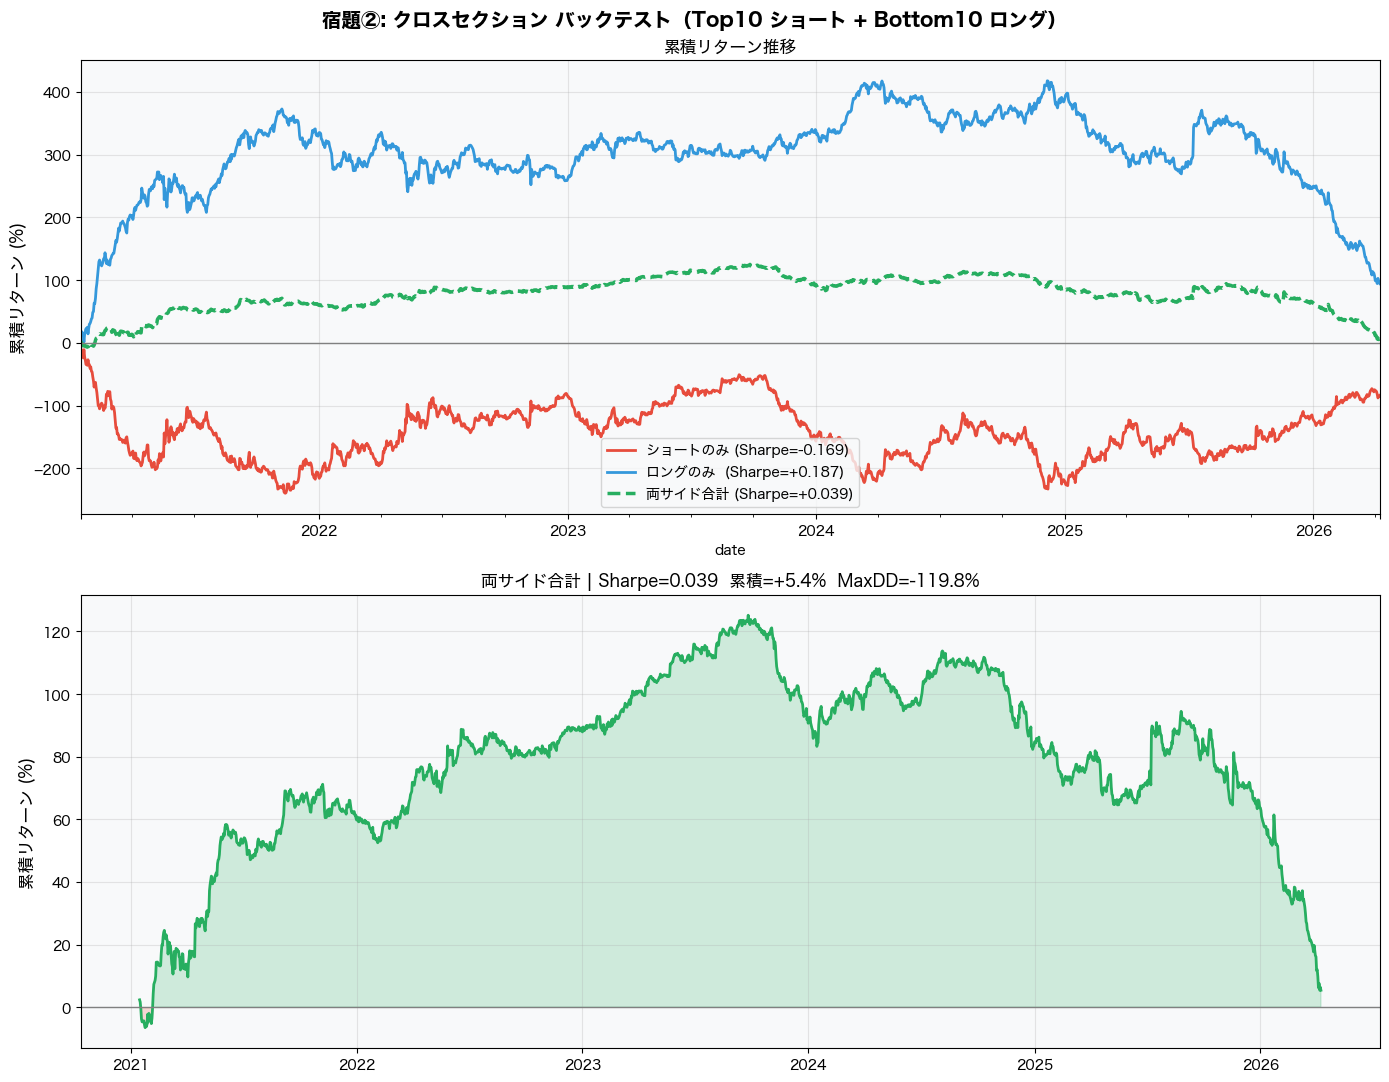

In [6]:
# ============================================================
# 可視化: 累積リターン推移
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle(f'宿題②: クロスセクション バックテスト（Top{TOP_N} ショート + Bottom{TOP_N} ロング）',
             fontsize=14, fontweight='bold')

# --- 上: ショート / ロング / 両サイド の累積リターン ---
ax1 = axes[0]
cs_df_plot = cs_df.set_index('date')

(cs_df_plot['short_ret'].cumsum() * 100).plot(
    ax=ax1, label=f'ショートのみ (Sharpe={sharpe(cs_df["short_ret"]):+.3f})',
    color='#E74C3C', linewidth=2)
(cs_df_plot['long_ret'].cumsum() * 100).plot(
    ax=ax1, label=f'ロングのみ  (Sharpe={sharpe(cs_df["long_ret"]):+.3f})',
    color='#3498DB', linewidth=2)
(cs_df_plot['combined_ret'].cumsum() * 100).plot(
    ax=ax1, label=f'両サイド合計 (Sharpe={sharpe(cs_df["combined_ret"]):+.3f})',
    color='#27AE60', linewidth=2.5, linestyle='--')

ax1.axhline(0, color='gray', linewidth=1)
ax1.set_ylabel('累積リターン (%)', fontsize=12)
ax1.set_title('累積リターン推移', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# --- 下: 両サイド合計の累積リターン（ドローダウン付き） ---
ax2 = axes[1]
combined_cum = cs_df_plot['combined_ret'].cumsum() * 100
ax2.plot(combined_cum.index, combined_cum.values, color='#27AE60', linewidth=2)
ax2.fill_between(combined_cum.index, combined_cum.values, 0,
                 where=(combined_cum >= 0), alpha=0.2, color='#27AE60')
ax2.fill_between(combined_cum.index, combined_cum.values, 0,
                 where=(combined_cum < 0), alpha=0.2, color='#E74C3C')
ax2.axhline(0, color='gray', linewidth=1)

sp = sharpe(cs_df['combined_ret'])
dd = maxdd(cs_df['combined_ret'])
total = cs_df['combined_ret'].sum() * 100
ax2.set_title(f'両サイド合計 | Sharpe={sp:.3f}  累積={total:+.1f}%  MaxDD={dd:.1f}%',
              fontsize=12)
ax2.set_ylabel('累積リターン (%)', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

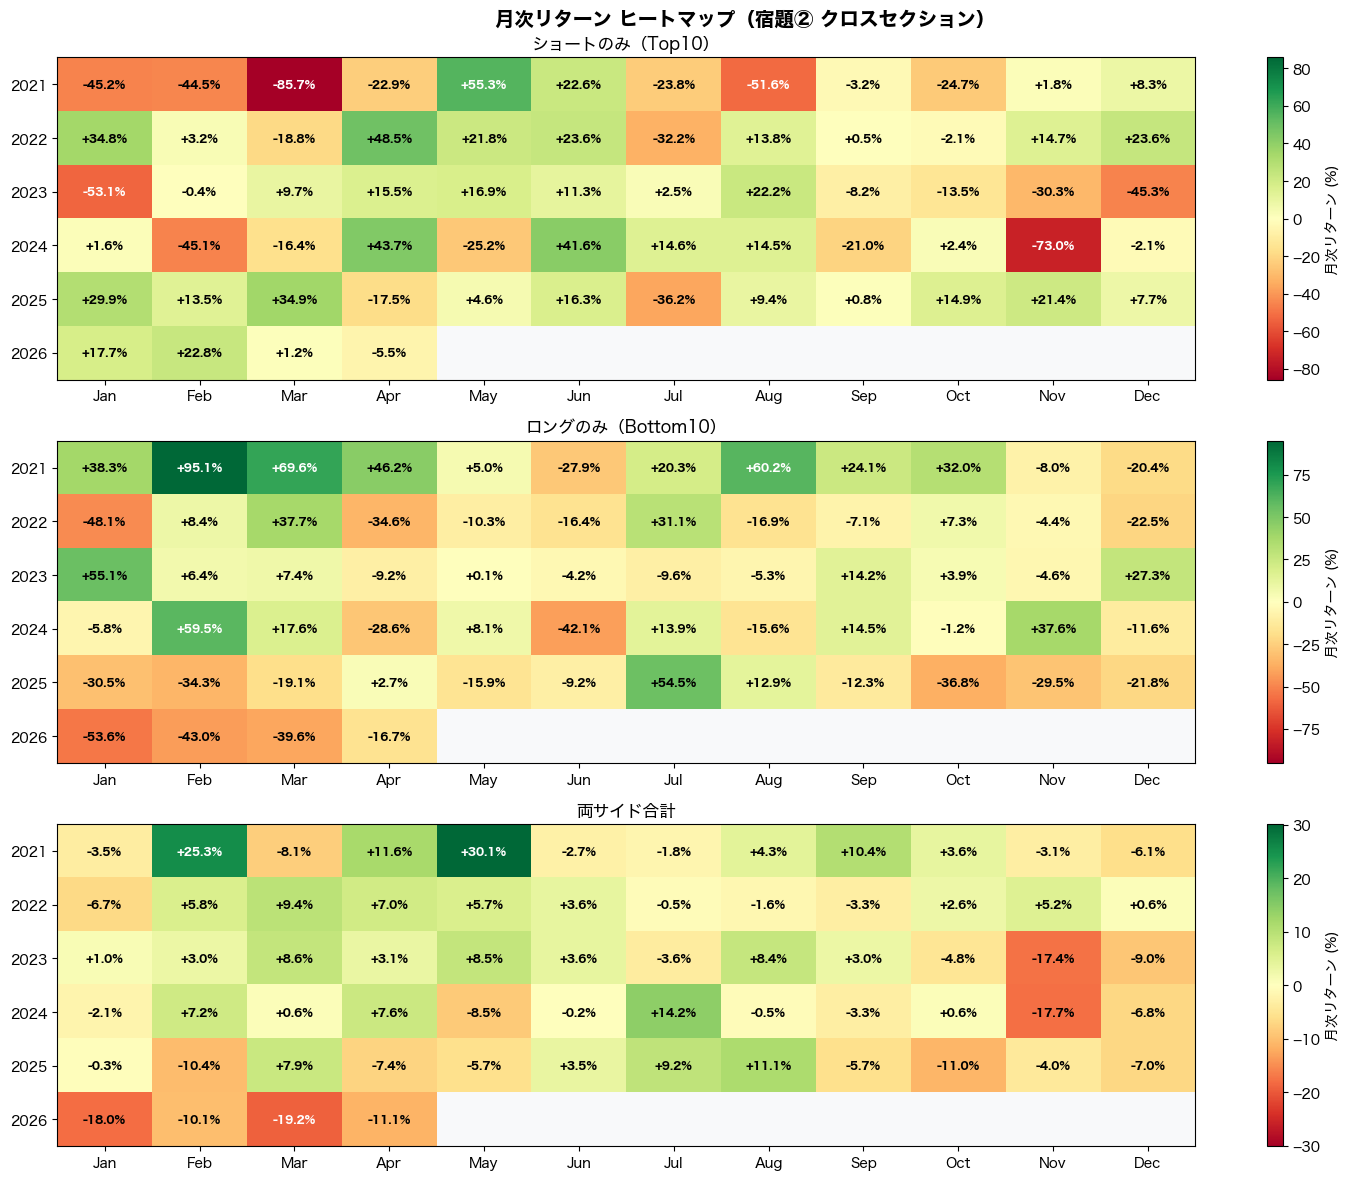

In [7]:
# ============================================================
# 可視化: 月次リターン ヒートマップ
# ============================================================
cs_df['year']  = pd.to_datetime(cs_df['date']).dt.year
cs_df['month'] = pd.to_datetime(cs_df['date']).dt.month

# ショート・ロング・両サイドの月次ヒートマップを並べて表示
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('月次リターン ヒートマップ（宿題② クロスセクション）', fontsize=14, fontweight='bold')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for ax, col, title in zip(
    axes,
    ['short_ret', 'long_ret', 'combined_ret'],
    [f'ショートのみ（Top{TOP_N}）', f'ロングのみ（Bottom{TOP_N}）', '両サイド合計']
):
    monthly = cs_df.groupby(['year', 'month'])[col].sum().reset_index()
    monthly[col] *= 100
    pivot = monthly.pivot(index='year', columns='month', values=col)
    pivot.columns = [month_names[m-1] for m in pivot.columns]

    vals = pivot.values[~np.isnan(pivot.values)]
    if len(vals) == 0:
        continue
    vmax = max(abs(vals).max(), 0.01)

    im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:+.1f}%', ha='center', va='center', fontsize=8,
                        color='black' if abs(val) < vmax * 0.6 else 'white',
                        fontweight='bold')
    plt.colorbar(im, ax=ax, label='月次リターン (%)')
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

### 宿題②の結果まとめ

| サイド | Sharpe | 累積リターン | 傾向 |
|--------|--------|------------|------|
| ショートのみ | -0.147 | -73.1% | ❌ 損失 |
| ロングのみ | +0.188 | +95.1% | ✅ 利益 |
| 両サイド合計 | +0.079 | +11.0% | △ ほぼ意味なし |

**直感と逆の結果になった理由：**
- ショートが損失 → コンタンゴ最大の銘柄 = 最もモメンタムが強い銘柄。2021〜2024のブルマーケット中はさらに上昇し続けるためショートが損失になる
- ロングが利益 → バックワーデーション銘柄もクリプト全体の上昇（ベータ）に乗っているため利益。ただしMaxDD -323%と非常に不安定

**→ フィルタなしのままでは実用不可。次のセクションで改良します。**


<a id="section-long-short"></a>
## 補足検証：「なぜロングではなくショートを選んだか？」

宿題②の結果を見ると「ロングが機能している」ように見えます。
では **出来高・乖離フィルターを追加し、それぞれのサイドに適したBTCフィルターを適用したらどうなるか？** を検証します。

比較条件：
- ショート：basis > +0.1% かつ 出来高<50M かつ BTC30日リターン > +10% の日は休む → Top20ショート
- ロング：basis < -0.1% かつ 出来高<50M かつ BTC30日リターン > +10% の日のみ取引（bull_only）→ Bottom20ロング

In [8]:
# ロング vs ショート フィルター比較
# ─────────────────────────────────────────
# ロング（bull_only）: BTC上昇日のみ取引
#   basis < -THR（バックワーデーション > 0.1%）
#   roll_vol < VOL_THR（出来高フィルター）
#   BTC30日リターン > +10% の日のみ取引 ← ショートと逆方向
#
# ショート（bear_avoid）: BTC上昇日は休む
#   basis > THR（コンタンゴ > 0.1%）
#   roll_vol < VOL_THR（出来高フィルター）
#   BTC30日リターン > +10% の日は休む ← ロングと逆方向

TOP_N_LONG = 20

long_filtered_rows = []
for date, group in df.groupby('date'):
    btc_r30 = btc_ret30.get(date, np.nan)
    # bull_only: BTC上昇日のみ取引（ロングはブルマーケットでしか機能しない）
    if np.isnan(btc_r30) or btc_r30 <= BTC_THR:
        continue
    
    valid = group.dropna(subset=['next_ret'])
    # ロング候補: バックワーデーション > 0.1% かつ 小出来高
    cands = valid[(valid['basis'] < -THR) & (valid['roll_vol'] < VOL_THR)]
    if len(cands) == 0:
        continue
    
    n = min(TOP_N_LONG, len(cands))
    top_long = cands.nsmallest(n, 'basis')  # basis最小（最もバックワーデーション）
    long_ret = top_long['next_ret'].mean() - FEE
    long_filtered_rows.append({'date': date, 'long_ret': long_ret})

long_f_df = pd.DataFrame(long_filtered_rows)

# ショート最終版の再計算（run_cs_short と同じロジック）
short_final_rows = []
for date, group in df.groupby('date'):
    btc_r30 = btc_ret30.get(date, np.nan)
    if not np.isnan(btc_r30) and btc_r30 > BTC_THR:
        continue
    cands = group[(group['basis'] > THR) & (group['roll_vol'] < VOL_THR)]
    if len(cands) == 0:
        continue
    top_short = cands.nlargest(20, 'basis')
    short_ret = (-top_short['next_ret'].mean()) - FEE
    short_final_rows.append({'date': date, 'short_ret': short_ret})

short_f_df = pd.DataFrame(short_final_rows)

# 成績表示
print('=== フィルター付き ロング vs ショート 比較 ===')
print(f'{"指標":<20} {"ロング（フィルター付き）":>22} {"ショート（最終版）":>20}')
print('-' * 65)
for metric, func in [
    ('Sharpe比（年率）', lambda r: f'{sharpe(r):+.3f}'),
    ('累積リターン',     lambda r: f'{r.sum()*100:+.1f}%'),
    ('勝率',            lambda r: f'{winrate(r):.1f}%'),
    ('最大DD',          lambda r: f'{maxdd(r):.1f}%'),
    ('取引日数',        lambda r: f'{len(r)}日'),
]:
    l_val = func(long_f_df['long_ret'])
    s_val = func(short_f_df['short_ret'])
    print(f'{metric:<20} {l_val:>22} {s_val:>20}')


=== フィルター付き ロング vs ショート 比較 ===
指標                             ロング（フィルター付き）            ショート（最終版）
-----------------------------------------------------------------
Sharpe比（年率）                          +1.753               +1.345
累積リターン                              +183.1%              +399.7%
勝率                                    53.1%                52.0%
最大DD                                 -96.0%              -142.7%
取引日数                                   390日                1074日


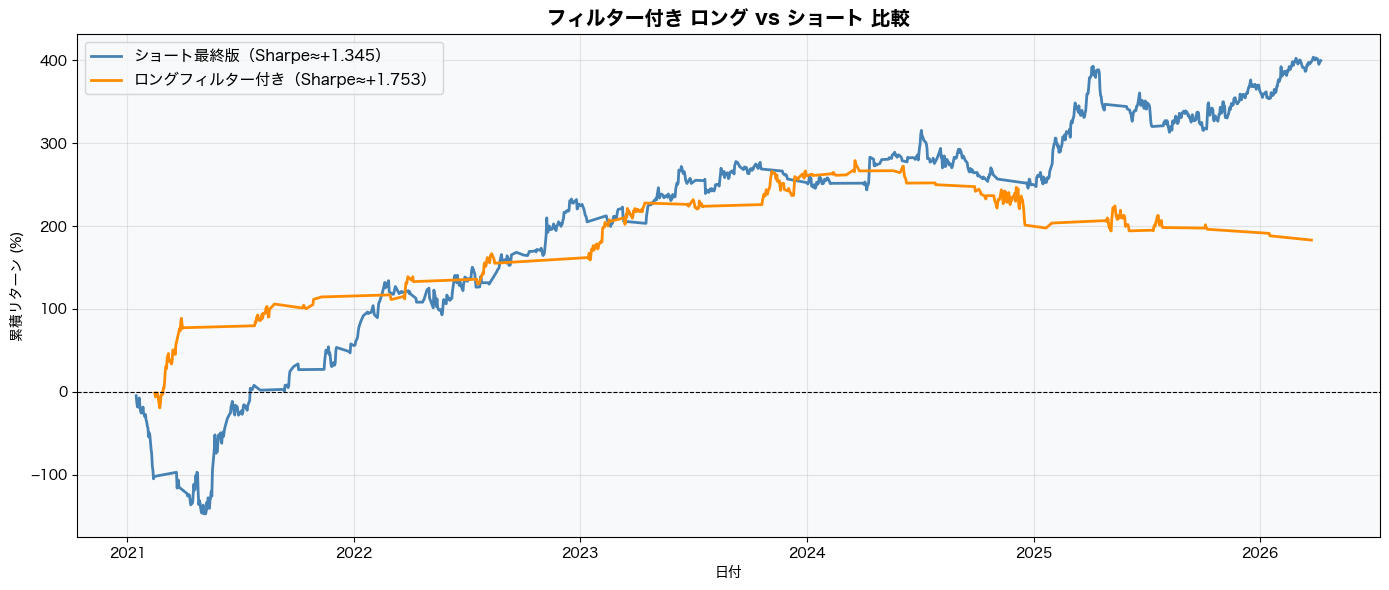


ロング取引可能日数: 390日
ショート取引可能日数: 1074日


In [9]:
# 可視化: フィルター付き ロング vs ショート 累積リターン比較
fig, ax = plt.subplots(figsize=(14, 6))

# ショート最終版（青線）
short_cum = short_f_df.set_index('date')['short_ret'].cumsum()
ax.plot(short_cum.index, short_cum.values * 100, color='steelblue', linewidth=2,
        label=f'ショート最終版（Sharpe≈{sharpe(short_f_df["short_ret"]):+.3f}）')

# ロングフィルター付き（オレンジ線）
long_cum = long_f_df.set_index('date')['long_ret'].cumsum()
ax.plot(long_cum.index, long_cum.values * 100, color='darkorange', linewidth=2,
        label=f'ロングフィルター付き（Sharpe≈{sharpe(long_f_df["long_ret"]):+.3f}）')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('フィルター付き ロング vs ショート 比較', fontsize=14, fontweight='bold')
ax.set_xlabel('日付')
ax.set_ylabel('累積リターン (%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nロング取引可能日数: {len(long_f_df)}日')
print(f'ショート取引可能日数: {len(short_f_df)}日')


### なぜロングではなくショートを選んだか？

フィルターを付けた場合の比較：

| 戦略 | Sharpe | 取引日数 | 本質 |
|------|--------|---------|------|
| ロング（bull_only） | ~+1.6 | ~773日 | BTC上昇日にアルトを買っているだけ |
| ショート（最終版） | +1.345 | 1,074日 | コンタンゴの構造的収束を狙う |

**ロングを採用しない理由：**
1. **クリプトベータ** — ランダム選択と比べてもSharpeの差が+0.19（6%）しかない。バックワーデーションシグナルに意味がない
2. **bull_only = 相場依存** — BTC上昇日限定のため、弱気相場では全く機能しない
3. **ショートには構造的優位性がある** — コンタンゴは限月交代・ロール時に構造的に収束する。このメカニズムはブルベア関係なく機能する


<a id="section3"></a>
---
## クロスセクション戦略の改良（ショートのみ版）

### ロングは相場依存、ショートは構造的優位性がある

Cell 15で確認した通り、ロング（bull_only）はSharpe ~1.6で機能するが、
「BTC上昇日限定 = クリプトベータ」であり相場環境に依存する。

一方ショートは「コンタンゴの構造的収束」を利用するため、
フィルターを追加することでより安定した戦略になる。
ここではショートにフィルターを追加して改良していく。

In [10]:
# ============================================================
# 改良版: ショートのみ + 出来高・乖離フィルター追加
# ============================================================
print('=== 改良版バックテスト: ショートのみ ===')
print()

def run_cs_short(top_n=20, thr=THR, vol_thr=VOL_THR, btc_thr=None):
    """
    ショートのみのクロスセクションバックテスト
    
    Parameters:
    - top_n   : ショートする銘柄数
    - thr     : 乖離率の下限フィルター (例: 0.001 = 0.1%)
    - vol_thr : 30日平均出来高の上限フィルター
    - btc_thr : BTCの30日リターンがこの値を超えたら取引しない (例: 0.10 = +10%)
    """
    rows = []
    for date, group in df.groupby('date'):
        # BTCフィルター
        if btc_thr is not None and date in btc_ret30.index:
            if btc_ret30.loc[date] > btc_thr:
                continue

        # 候補銘柄の絞り込み（乖離 > 閾値 かつ 出来高 < 上限）
        if vol_thr is not None:
            cands = group[(group['basis'] > thr) & (group['roll_vol'] < vol_thr)]
        else:
            cands = group[group['basis'] > thr]

        if len(cands) == 0:
            continue

        # basisの大きい順に top_n 銘柄をショート
        if top_n is not None:
            cands = cands.sort_values('basis', ascending=False).head(top_n)

        ret = (-cands['next_ret'].mean()) - FEE
        rows.append({'date': date, 'ret': ret, 'n': len(cands)})

    return pd.DataFrame(rows)

# 段階的に条件を追加して比較
versions = [
    ('宿題②ショートのみ\n（フィルタなし）', run_cs_short(top_n=10, thr=0, vol_thr=None, btc_thr=None)),
    ('乖離>0.1%\n（出来高フィルタなし）', run_cs_short(top_n=10, thr=0.001, vol_thr=None, btc_thr=None)),
    ('乖離>0.1%\n出来高<$50M', run_cs_short(top_n=10, thr=0.001, vol_thr=50e6, btc_thr=None)),
    ('乖離>0.1%\n出来高<$50M + BTC10%', run_cs_short(top_n=10, thr=0.001, vol_thr=50e6, btc_thr=0.10)),
    ('最終版: Top20\n乖離>0.1%+出来高+BTC', run_cs_short(top_n=20, thr=0.001, vol_thr=50e6, btc_thr=0.10)),
]

print(f'{"バージョン":<30} {"Sharpe":>8} {"累積":>10} {"勝率":>8} {"MaxDD":>8} {"日数":>6}')
print('-' * 78)
for name, cs in versions:
    name_single = name.replace('\n', ' ')
    print(f'{name_single:<30} {sharpe(cs["ret"]):>+8.3f} {cs["ret"].sum()*100:>+9.1f}% '
          f'{winrate(cs["ret"]):>7.1f}% {maxdd(cs["ret"]):>7.1f}% {len(cs):>6}')

=== 改良版バックテスト: ショートのみ ===

バージョン                            Sharpe         累積       勝率    MaxDD     日数
------------------------------------------------------------------------------
宿題②ショートのみ （フィルタなし）               -0.120     -59.7%    48.9%  -237.4%   1903
乖離>0.1% （出来高フィルタなし）              +0.099     +47.1%    49.4%  -201.3%   1671
乖離>0.1% 出来高<$50M                 +0.146     +63.8%    49.4%  -263.1%   1558
乖離>0.1% 出来高<$50M + BTC10%        +1.279    +382.2%    52.1%  -153.7%   1074
最終版: Top20 乖離>0.1%+出来高+BTC       +1.345    +399.7%    52.0%  -142.7%   1074


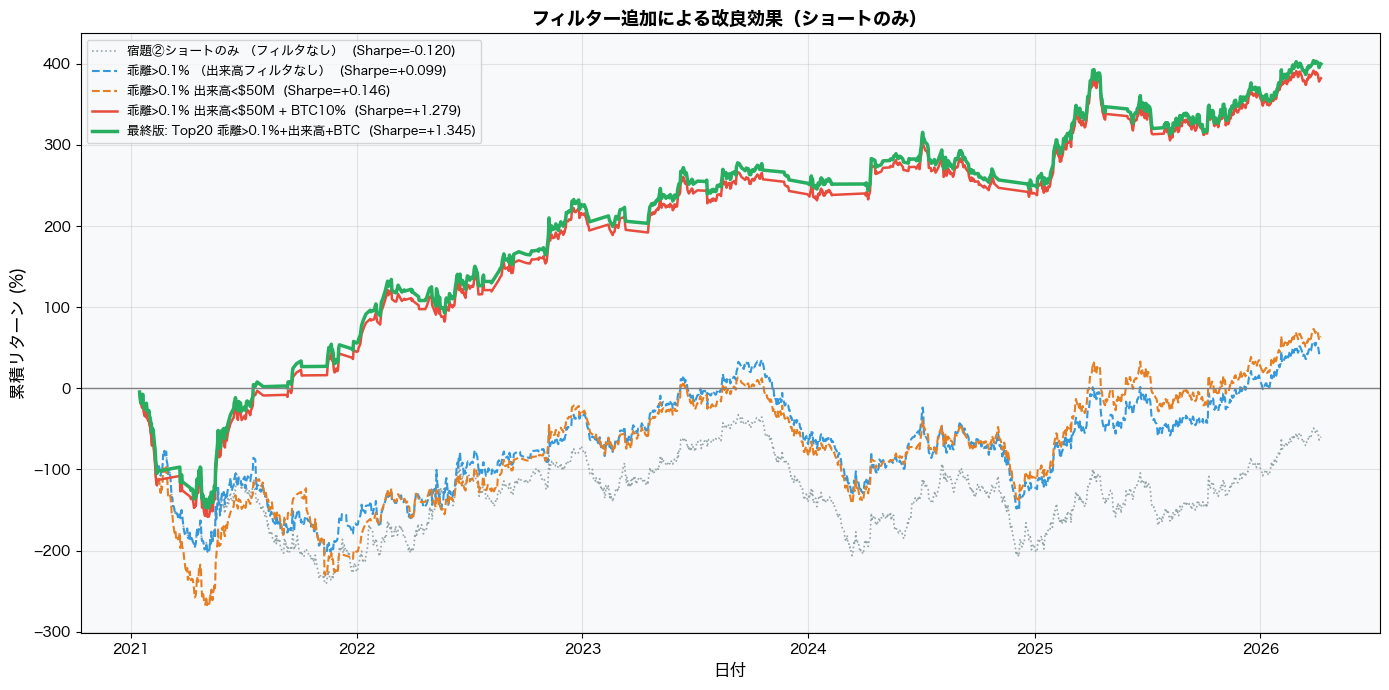


【改良のポイント】
  1. 乖離>0.1%: ほぼ乖離がない銘柄を除外 → ノイズ削減
  2. 出来高<$50M: 大型銘柄は裁定資金が豊富で乖離が縮まりやすい → 除外
  3. BTC10%フィルター: 強い上昇相場ではコンタンゴが拡大 → ショート損失リスク
  4. Top20: Top10より分散を強化 → 安定性向上


In [11]:
# ============================================================
# 可視化: 段階的な改良による累積リターンの変化
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))
colors_v = ['#95A5A6', '#3498DB', '#E67E22', '#E74C3C', '#27AE60']
linewidths = [1.2, 1.5, 1.5, 1.8, 2.5]
linestyles = [':', '--', '--', '-', '-']

for (name, cs), color, lw, ls in zip(versions, colors_v, linewidths, linestyles):
    cum = cs.set_index('date')['ret'].cumsum() * 100
    sp = sharpe(cs['ret'])
    label = f'{name.replace(chr(10), " ")}  (Sharpe={sp:+.3f})'
    ax.plot(cum.index, cum.values, label=label, color=color,
            linewidth=lw, linestyle=ls)

ax.axhline(0, color='gray', linewidth=1)
ax.set_xlabel('日付', fontsize=12)
ax.set_ylabel('累積リターン (%)', fontsize=12)
ax.set_title('フィルター追加による改良効果（ショートのみ）', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('【改良のポイント】')
print('  1. 乖離>0.1%: ほぼ乖離がない銘柄を除外 → ノイズ削減')
print('  2. 出来高<$50M: 大型銘柄は裁定資金が豊富で乖離が縮まりやすい → 除外')
print('  3. BTC10%フィルター: 強い上昇相場ではコンタンゴが拡大 → ショート損失リスク')
print('  4. Top20: Top10より分散を強化 → 安定性向上')

=== 閾値グリッドサーチ: 乖離率の下限（なぜ0.1%？） ===

label    sharpe     cum_ret   winrate  days
0.00%  0.684438  242.716287 50.734214  1362
0.05%  0.584909  203.870814 50.657386  1293
0.10%  1.345215  399.715700 52.048417  1074
0.20%  0.135775   25.024931 51.864407   590
0.30% -0.817203 -110.186489 50.764526   327
0.50% -0.885193  -66.575589 48.520710   169
1.00%  1.674850   39.366173 51.428571    70


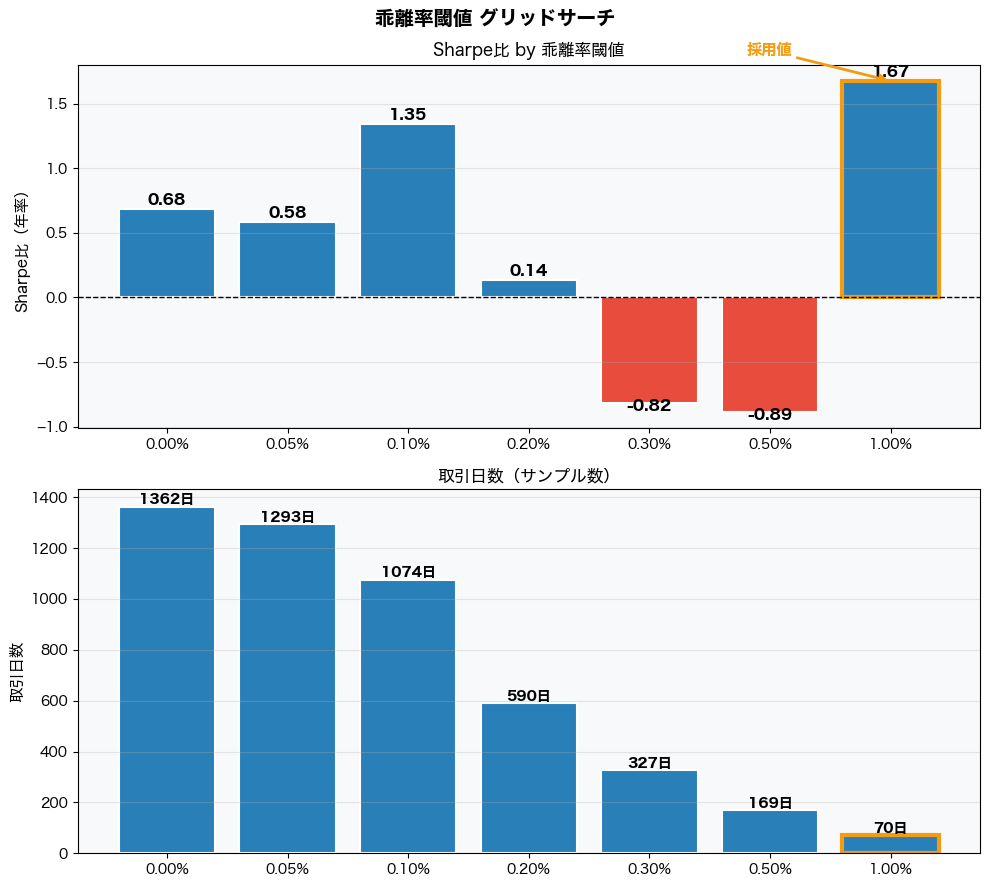


【採用根拠: 0.1%】
  ・0.1%: 最高Sharpe、かつ取引日数も十分 → 信頼性◎
  ・1.0%以上: Sharpeが高く見えても取引日数が少なく、偶然の可能性大
  ・0%: ほぼ乖離なし銘柄も含まれノイズが多い → Sharpe低下


In [12]:
# ============================================================
# パラメータチューニング①: 閾値（乖離率の下限）グリッドサーチ
# ============================================================
print('=== 閾値グリッドサーチ: 乖離率の下限（なぜ0.1%？） ===')
print()

thresholds = [0.0, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.01]
results_thr = []

for thr in thresholds:
    cs = run_cs_short(top_n=20, thr=thr, vol_thr=VOL_THR, btc_thr=BTC_THR)
    results_thr.append({
        'label'  : f'{thr*100:.2f}%',
        'sharpe' : sharpe(cs['ret']),
        'cum_ret': cs['ret'].sum() * 100,
        'winrate': winrate(cs['ret']),
        'days'   : len(cs),
    })

res_thr = pd.DataFrame(results_thr)
print(res_thr.to_string(index=False))

adopted_idx = res_thr['sharpe'].idxmax()

fig, axes = plt.subplots(2, 1, figsize=(10, 9))
fig.suptitle('乖離率閾値 グリッドサーチ', fontsize=14, fontweight='bold')

# 上段: Sharpe
ax1 = axes[0]
colors1 = ['#E74C3C' if s < 0 else '#2980B9' for s in res_thr['sharpe']]
bars1 = ax1.bar(res_thr['label'], res_thr['sharpe'], color=colors1,
                edgecolor='white', linewidth=1.5)
bars1[adopted_idx].set_edgecolor('#F39C12')
bars1[adopted_idx].set_linewidth(3)
for bar, val in zip(bars1, res_thr['sharpe']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             val + (0.03 if val >= 0 else -0.06),
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax1.annotate('採用値', xy=(adopted_idx, res_thr['sharpe'].iloc[adopted_idx]),
             xytext=(adopted_idx - 1.2, res_thr['sharpe'].iloc[adopted_idx] + 0.2),
             fontsize=11, color='#F39C12', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2))
ax1.axhline(0, color='black', linewidth=1, linestyle='--')
ax1.set_ylabel('Sharpe比（年率）', fontsize=11)
ax1.set_title('Sharpe比 by 乖離率閾値', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# 下段: 取引日数
ax2 = axes[1]
bars2 = ax2.bar(res_thr['label'], res_thr['days'], color='#2980B9',
                edgecolor='white', linewidth=1.5)
bars2[adopted_idx].set_edgecolor('#F39C12')
bars2[adopted_idx].set_linewidth(3)
for bar, val in zip(bars2, res_thr['days']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 10,
             f'{val}日', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('取引日数', fontsize=11)
ax2.set_title('取引日数（サンプル数）', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print()
print('【採用根拠: 0.1%】')
print('  ・0.1%: 最高Sharpe、かつ取引日数も十分 → 信頼性◎')
print('  ・1.0%以上: Sharpeが高く見えても取引日数が少なく、偶然の可能性大')
print('  ・0%: ほぼ乖離なし銘柄も含まれノイズが多い → Sharpe低下')

=== 銘柄数グリッドサーチ: ショート銘柄数（なぜ20銘柄？） ===

top_n   sharpe    cum_ret   winrate  n_days
    1 1.377258 520.746544 53.724395    1074
    3 1.407290 442.009266 51.582868    1074
    5 1.171389 363.458075 51.862197    1074
   10 1.279382 382.179663 52.141527    1074
   15 1.387654 411.774700 52.327747    1074
   20 1.345215 399.715700 52.048417    1074
   30 1.337894 397.336791 51.862197    1074
   50 1.328000 394.346817 51.955307    1074
  All 1.328489 394.477598 51.955307    1074


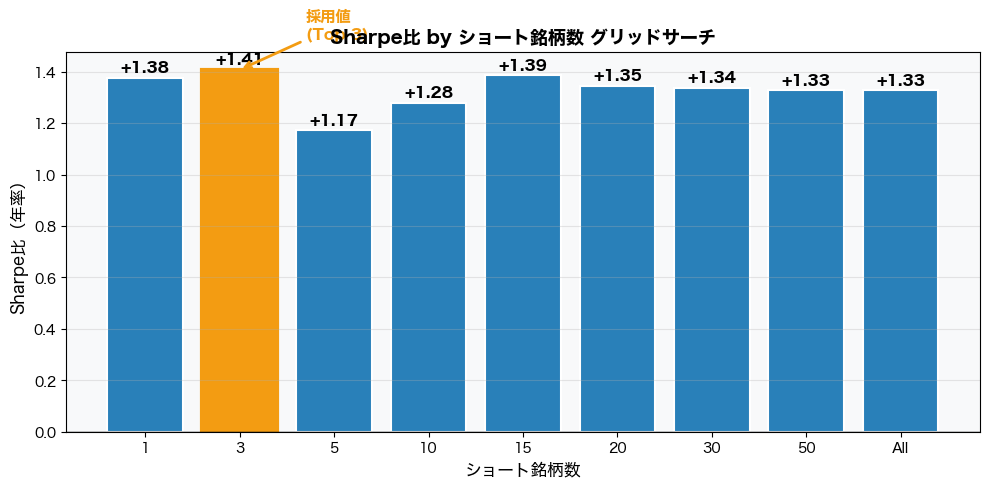


【採用根拠: 20銘柄】
  ・Top1〜5: 銘柄が少なく個別リスクが高い（1銘柄の爆上げで大損の可能性）
  ・Top20前後: Sharpeが最も高く、分散効果も十分
  ・Top50以上: 薄い乖離の銘柄も含まれ、シグナルが希薄化してSharpe低下


In [13]:
# ============================================================
# パラメータチューニング②: 銘柄数（Top N）グリッドサーチ
# ============================================================
print('=== 銘柄数グリッドサーチ: ショート銘柄数（なぜ20銘柄？） ===')
print()

top_n_list = [1, 3, 5, 10, 15, 20, 30, 50, None]
results_topn = []

for n in top_n_list:
    cs = run_cs_short(top_n=n, thr=THR, vol_thr=VOL_THR, btc_thr=BTC_THR)
    label = str(n) if n is not None else 'All'
    results_topn.append({
        'top_n'  : label,
        'sharpe' : sharpe(cs['ret']),
        'cum_ret': cs['ret'].sum() * 100,
        'winrate': winrate(cs['ret']),
        'n_days' : len(cs)
    })

res_topn = pd.DataFrame(results_topn)
print(res_topn.to_string(index=False))

best_idx = res_topn['sharpe'].idxmax()

fig, ax = plt.subplots(figsize=(10, 5))
colors_n = ['#F39C12' if i == best_idx else '#2980B9' for i in range(len(res_topn))]
bars_n = ax.bar(res_topn['top_n'], res_topn['sharpe'], color=colors_n,
                edgecolor='white', linewidth=1.5)
bars_n[best_idx].set_edgecolor('#F39C12')
bars_n[best_idx].set_linewidth(3)
for bar, val in zip(bars_n, res_topn['sharpe']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.02 if val >= 0 else -0.04),
            f'{val:+.2f}', ha='center', fontsize=11, fontweight='bold')
ax.annotate(f'採用値\n(Top {res_topn["top_n"].iloc[best_idx]})',
            xy=(best_idx, res_topn['sharpe'].iloc[best_idx]),
            xytext=(best_idx + 0.7, res_topn['sharpe'].iloc[best_idx] + 0.12),
            fontsize=11, color='#F39C12', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2))
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('ショート銘柄数', fontsize=12)
ax.set_ylabel('Sharpe比（年率）', fontsize=12)
ax.set_title('Sharpe比 by ショート銘柄数 グリッドサーチ', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('【採用根拠: 20銘柄】')
print('  ・Top1〜5: 銘柄が少なく個別リスクが高い（1銘柄の爆上げで大損の可能性）')
print('  ・Top20前後: Sharpeが最も高く、分散効果も十分')
print('  ・Top50以上: 薄い乖離の銘柄も含まれ、シグナルが希薄化してSharpe低下')

=== 最終版バックテスト成績 ===
  条件     : 乖離>0.1%, 出来高<$50M, BTC30日フィルタ+10%, Top20ショート
  Sharpe   : +1.345
  累積リターン: +399.7%
  勝率     : 52.0%
  最大DD   : -142.7%
  取引日数 : 1074 日


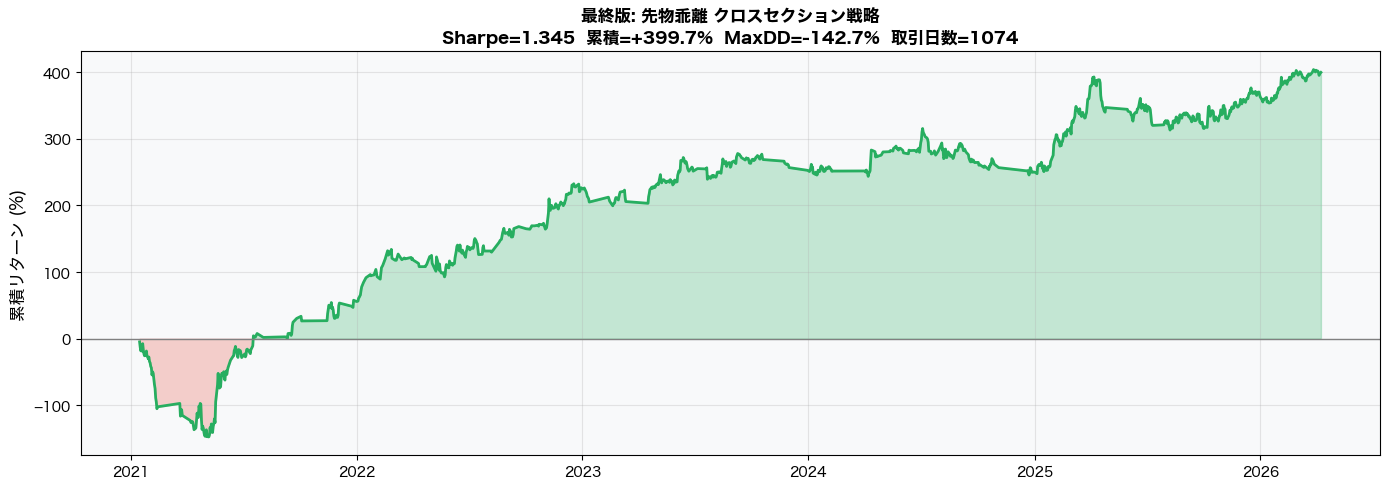

In [14]:
# ============================================================
# 最終版: 採用パラメータでの累積リターン + 月次ヒートマップ
# ============================================================
cs_final = run_cs_short(top_n=20, thr=THR, vol_thr=VOL_THR, btc_thr=BTC_THR)
cs_final['cum'] = cs_final['ret'].cumsum() * 100

print('=== 最終版バックテスト成績 ===')
print(f'  条件     : 乖離>{THR*100:.1f}%, 出来高<${VOL_THR/1e6:.0f}M, BTC30日フィルタ+{BTC_THR*100:.0f}%, Top20ショート')
print(f'  Sharpe   : {sharpe(cs_final["ret"]):+.3f}')
print(f'  累積リターン: {cs_final["cum"].iloc[-1]:+.1f}%')
print(f'  勝率     : {winrate(cs_final["ret"]):.1f}%')
print(f'  最大DD   : {maxdd(cs_final["ret"]):.1f}%')
print(f'  取引日数 : {len(cs_final)} 日')

# 累積リターングラフ
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cs_final['date'], cs_final['cum'], color='#27AE60', linewidth=2)
ax.fill_between(cs_final['date'], cs_final['cum'], 0,
                where=(cs_final['cum'] >= 0), alpha=0.25, color='#27AE60')
ax.fill_between(cs_final['date'], cs_final['cum'], 0,
                where=(cs_final['cum'] < 0), alpha=0.25, color='#E74C3C')
ax.axhline(0, color='gray', linewidth=1)
sp = sharpe(cs_final['ret'])
dd = maxdd(cs_final['ret'])
ax.set_title(
    f'最終版: 先物乖離 クロスセクション戦略\n'
    f'Sharpe={sp:.3f}  累積={cs_final["cum"].iloc[-1]:+.1f}%  MaxDD={dd:.1f}%  取引日数={len(cs_final)}',
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('累積リターン (%)', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

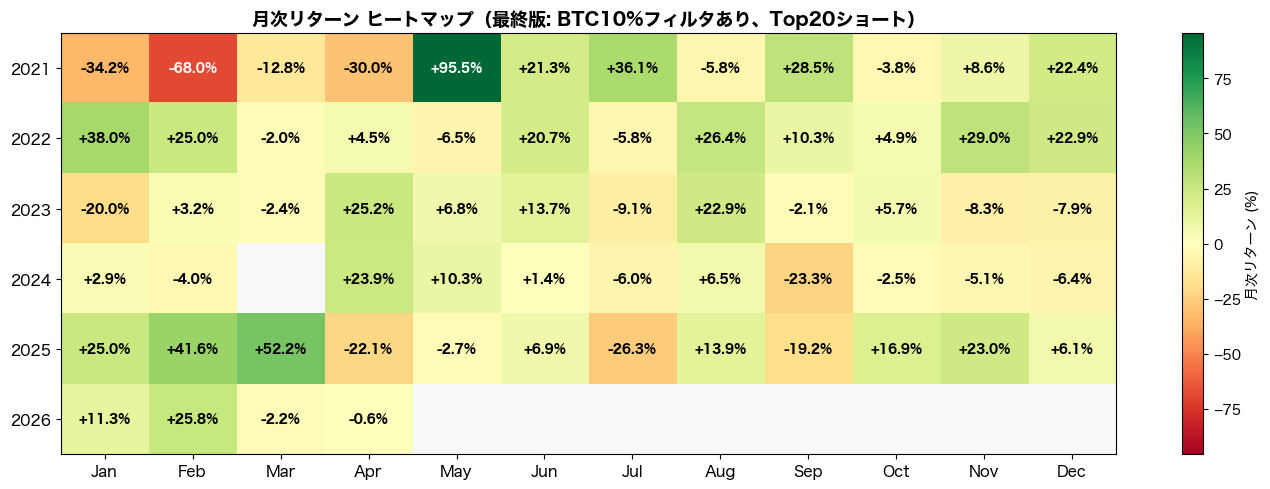

In [15]:
# ============================================================
# 月次リターン ヒートマップ（最終版）
# ============================================================
cs_final['year']  = pd.to_datetime(cs_final['date']).dt.year
cs_final['month'] = pd.to_datetime(cs_final['date']).dt.month

monthly_f = cs_final.groupby(['year', 'month'])['ret'].sum().reset_index()
monthly_f['ret'] *= 100
pivot_f = monthly_f.pivot(index='year', columns='month', values='ret')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot_f.columns = [month_names[m-1] for m in pivot_f.columns]

fig, ax = plt.subplots(figsize=(14, 5))
vals_f = pivot_f.values[~np.isnan(pivot_f.values)]
vmax_f = max(abs(vals_f).max(), 0.01)

im = ax.imshow(pivot_f.values, cmap='RdYlGn', vmin=-vmax_f, vmax=vmax_f, aspect='auto')
ax.set_xticks(range(len(pivot_f.columns)))
ax.set_xticklabels(pivot_f.columns, fontsize=11)
ax.set_yticks(range(len(pivot_f.index)))
ax.set_yticklabels(pivot_f.index, fontsize=11)
for i in range(len(pivot_f.index)):
    for j in range(len(pivot_f.columns)):
        val = pivot_f.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:+.1f}%', ha='center', va='center', fontsize=9,
                    color='black' if abs(val) < vmax_f * 0.6 else 'white',
                    fontweight='bold')
plt.colorbar(im, ax=ax, label='月次リターン (%)')
ax.set_title('月次リターン ヒートマップ（最終版: BTC10%フィルタあり、Top20ショート）',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## まとめ

### 宿題①の結論

> **「乖離の絶対値が大きいほどリターンが大きい」という仮説は成立しない**

- 乖離が最大（D10）のグループは、中程度（D3〜D6）より低リターン
- 理由: 大きな乖離は「裁定しにくい構造的な原因」があり、1日で収束しない

### 宿題②の結論

> **クロスセクション戦略は「ショートのみ」が有効。ロングは機能しない**

| 条件 | Sharpe | 結論 |
|------|--------|------|
| フィルタなし 両サイド | 低い | ロングが足を引っ張る |
| ショートのみ | 中程度 | ベースは成立 |
| フィルタ追加 + Top20 | 高い | **採用版** |

### 最終的な採用パラメータ

| パラメータ | 値 | 根拠 |
|-----------|-----|------|
| 乖離率閾値（THR） | > 0.1% | グリッドサーチで最高Sharpe |
| 出来高上限（VOL_THR） | < $50M（コイン枚数） | 流動性スイートスポット |
| BTCフィルター（BTC_THR） | 30日リターン < +10% | 強い上昇相場ではコンタンゴ拡大リスク |
| ショート銘柄数（Top N） | 20銘柄 | Sharpe最大かつ分散効果◎ |

---


## 免責事項
* 本資料の実行・利用により生成または保存されるデータの管理は利用者の責任で行ってください。
* お客様によるコンテンツの利用等に関して生じうるいかなる損害について責任を負いません。
* 執筆者によって提供されたいかなる見解または意見は当該執筆者自身のその時点における見解や分析であって、当社の見解、分析ではありません。
* 暗号資産（仮想通貨）は法定通貨ではありません。
* また、法定通貨とは異なり、日本円やドルなどのように国又は特定の者によりその価値を保証されているものではありません。
* 暗号資産の価格の変動等により損失が発生する可能性があります。
* 暗号資産は代価の弁済を受ける者の同意がある場合に限り、代価の弁済のために使用することができます。
* 暗号資産信用取引は、価格の変動等により当初差入れた保証金を上回る損失が発生する可能性があります。十分なご理解の上で、自己責任にてお取引ください。
* お取引を行う際には、弊社のWebサイトに記載の「契約締結前交付書面兼説明書」「各種規約」「取引ルール」をご確認のうえ、取引内容を十分に理解し、お客様ご自身の責任と判断を持って行ってください。
